# 03. Grid geoespacial y agregación de features de riesgo (Persona 3)

## Objetivo

Este notebook integra los datasets ya limpios de las tres fuentes de peligro
(sismos, ciclones, volcanes/España) sobre una única unidad de análisis
geoespacial: un **grid global H3**. El resultado es una tabla `celda x features`
lista para el preprocesamiento y PCA (Persona 4).

Fuentes de entrada (ya procesadas por Persona 1 y Persona 2):

- `data/processed/usgs_earthquakes_clean.csv`
- `data/processed/ciclones_clean.csv`
- `data/processed/volcanes_clean.csv`

La lógica reutilizable vive en `src/features/grid.py` y
`src/features/engineering.py`; este notebook se limita a cargar datos,
llamar a esas funciones, documentar decisiones y comprobar la calidad del
resultado antes de entregarlo a Persona 4.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)
pd.set_option("display.max_columns", None)

# Detectar la raíz del proyecto tanto si el notebook se ejecuta desde
# la carpeta principal como desde la carpeta notebooks/ (mismo patrón
# que usa Persona 1 en 01_eda_sismos.ipynb, para que todo el equipo
# navegue el repo de forma consistente).
CURRENT_DIRECTORY = Path.cwd()
PROJECT_ROOT = CURRENT_DIRECTORY if (CURRENT_DIRECTORY / "src").exists() else CURRENT_DIRECTORY.parent

import sys
sys.path.append(str(PROJECT_ROOT))

from src.features.grid import build_global_grid, assign_events_to_cells
from src.features.engineering import (
    compute_seismic_features,
    compute_cyclone_features,
    compute_volcanic_features,
)
from src.features.ingestion import deduplicar_usgs_vs_ign, combinar_sismos_usgs_ign

RESOLUTION = 3
print(f"Resolución H3 seleccionada: {RESOLUTION}")


Resolución H3 seleccionada: 3


## Elección de la resolución H3

H3 permite resoluciones de 0 (celdas continentales) a 15 (celdas de metros).
La elección es un compromiso directo entre dos riesgos:

- **Resolución demasiado baja** (celdas enormes): mezcla zonas de riesgo muy
  distinto dentro de la misma celda (ej. costa sísmica activa + interior
  tranquilo en la misma celda), diluyendo la señal que buscamos.
- **Resolución demasiado alta** (celdas diminutas): la inmensa mayoría de
  celdas del planeta quedaría vacía (océano abierto, desierto deshabitado),
  y muchas celdas con eventos tendrían muestras demasiado pequeñas para que
  las estadísticas agregadas (media, frecuencia) sean fiables.

Se utiliza **resolución 3** (celdas de un área media de ~12,000 km², del
orden de 100-200 km de lado), que da granularidad suficiente para distinguir
regiones dentro de un mismo país (ej. distintas zonas de España) sin
fragmentar en exceso la señal de eventos poco frecuentes como los ciclones.

In [2]:
grid = build_global_grid(resolution=RESOLUTION)
print(f"Celdas totales del grid global: {len(grid):,}")
grid.head()


Celdas totales del grid global: 41,162


,cell_id,lat,lon
0,83a205fffffffff,-19.153525,50.159594
1,8346e6fffffffff,21.114410,-167.893271
2,837bb2fffffffff,-0.491605,55.368580
3,83d769fffffffff,-50.198830,23.374294
4,83114dfffffffff,69.434243,45.469661


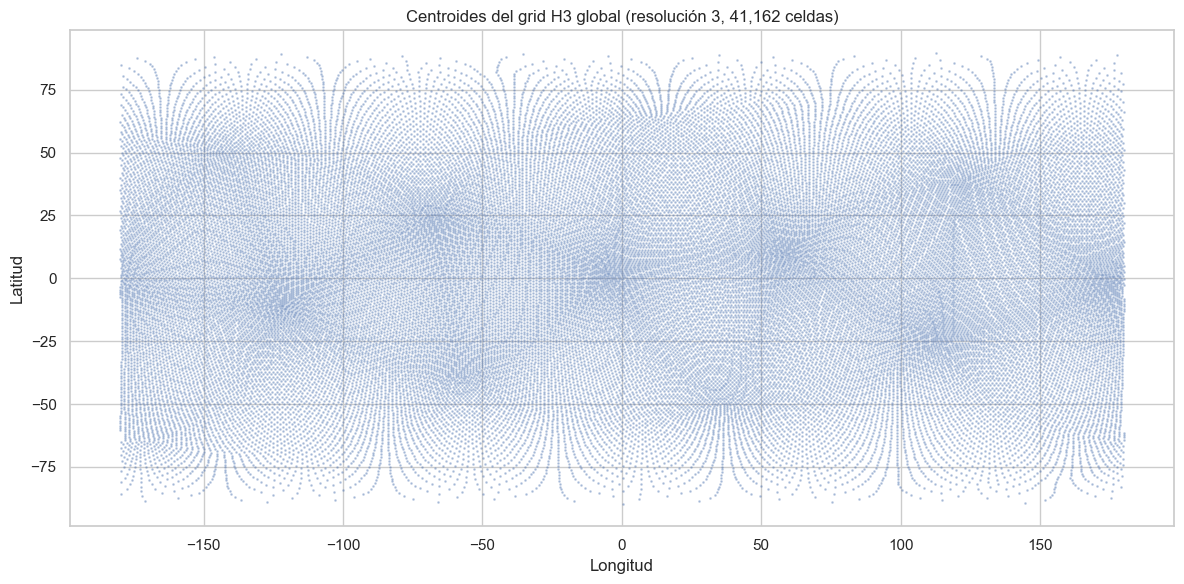

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(grid['lon'], grid['lat'], s=1, alpha=0.3)
ax.set_title(f"Centroides del grid H3 global (resolución {RESOLUTION}, {len(grid):,} celdas)")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.savefig('../outputs/figures/grid_global_h3.png', dpi=200)
plt.show()


### Interpretación

El grid cubre el planeta de forma uniforme en superficie (propiedad clave de
H3 frente a una malla lat/lon clásica, que distorsiona el tamaño de celda
cerca de los polos). En los siguientes pasos, cada celda solo tendrá valores
distintos de cero en las variables de un peligro si algún evento de ese tipo
cayó dentro de sus límites.

## 1. Carga de los datasets de entrada

Se cargan los tres CSV ya procesados por Persona 1 y Persona 2. Antes de
agregar nada, se comprueba que cada uno tiene el esquema de columnas que
esperan las funciones de `engineering.py` — este chequeo evita descubrir
un desajuste de columnas a mitad de la agregación (ya nos pasó una vez
durante la integración, ver historial de commits).

In [4]:
RAW_SISMOS_USGS = PROJECT_ROOT / "data" / "processed" / "usgs_earthquakes_clean.csv"
RAW_SISMOS_ESPANA = PROJECT_ROOT / "data" / "processed" / "espana_clean.csv"
RAW_CICLONES = PROJECT_ROOT / "data" / "processed" / "ciclones_clean.csv"
RAW_VOLCANES = PROJECT_ROOT / "data" / "processed" / "volcanes_clean.csv"

df_sismos_usgs = pd.read_csv(RAW_SISMOS_USGS)
df_sismos_espana = pd.read_csv(RAW_SISMOS_ESPANA)
df_ciclones = pd.read_csv(RAW_CICLONES)
df_volcanes = pd.read_csv(RAW_VOLCANES)


df_sismos_usgs_dedup = deduplicar_usgs_vs_ign(df_sismos_usgs, df_sismos_espana)

cols_comunes = ["timestamp", "lat", "lon", "depth_km", "magnitude"]
df_sismos = pd.concat(
    [df_sismos_usgs_dedup[cols_comunes], df_sismos_espana[cols_comunes]],
    ignore_index=True,
)
print(f"Total sismos combinados: {len(df_sismos):,}")

expected_cols = {
    "sismos": (df_sismos, ["timestamp", "lat", "lon", "depth_km", "magnitude"]),
    "ciclones": (df_ciclones, ["event_id", "timestamp", "lat", "lon", "wind", "pressure"]),
    "volcanes": (df_volcanes, ["lat", "lon"]),
}
for nombre, (df, cols) in expected_cols.items():
    faltantes = [c for c in cols if c not in df.columns]
    estado = "✅ OK" if not faltantes else f"❌ FALTAN: {faltantes}"
    print(f"{nombre:10s} -> {df.shape[0]:>8,} filas | columnas esperadas: {estado}")

C:\Users\jowel\AppData\Local\Temp\ipykernel_21632\3080873282.py:7: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sismos_espana = pd.read_csv(RAW_SISMOS_ESPANA)


USGS: 373 eventos identificados como duplicados de IGN (de 308,977 totales) -> se descartan
Total sismos combinados: 511,815
sismos     ->  511,815 filas | columnas esperadas: ✅ OK
ciclones   ->  646,984 filas | columnas esperadas: ✅ OK
volcanes   ->      200 filas | columnas esperadas: ✅ OK


In [5]:
# Comprobación rápida: ¿cuántos sismos hay por año, sobre todo en los últimos?
timestamps_tmp = pd.to_datetime(df_sismos['timestamp'], utc=True, format='mixed')
print(timestamps_tmp.dt.year.value_counts().sort_index().tail())

timestamp
2022    20076
2023    15148
2024    13197
2025    16536
2026     9678
Name: count, dtype: int64


## 2. Agregación sísmica

Ventana temporal: **1900-2025** (cobertura global de USGS razonablemente
fiable desde esa fecha para magnitud ≥4.5, ver `01_eda_sismos.ipynb` para el
análisis de sesgo temporal completo). Variables generadas por celda:

- `eq_count`: nº de sismos registrados
- `eq_mag_mean` / `eq_mag_max`: magnitud media / máxima
- `eq_depth_mean`: profundidad media
- `eq_energy_log`: energía sísmica acumulada (relación de Gutenberg-Richter,
  en escala logarítmica para no distorsionar el escalado posterior)
- `eq_days_since_last_major`: días desde el último evento de magnitud ≥6.0
  ("silencio sísmico" — clave para el caso de negocio de zonas de riesgo
  acumulado no liberado, ver conversación de equipo sobre Venezuela 2026)

In [6]:
eq_features = compute_seismic_features(df_sismos, resolution=RESOLUTION)
print(f"Celdas con al menos un sismo: {len(eq_features):,} de {len(grid):,} totales")
eq_features.describe()


Celdas con al menos un sismo: 8,870 de 41,162 totales


,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,eq_days_since_last_major
count,8870.000000,8867.000000,8867.000000,8870.000000,8867.000000,3237.000000
mean,57.701804,4.927091,5.700187,39.032293,13.557256,15283.553290
std,498.083839,0.538470,0.928968,82.115330,1.439839,12986.310538
min,1.000000,1.256074,1.600000,-2.540000,7.331879,6.000000
25%,1.000000,4.750000,4.900000,10.000000,12.300000,4095.000000
50%,5.000000,4.900000,5.600000,15.858259,13.478189,11078.000000
75%,27.000000,5.098322,6.315000,31.348370,14.581198,25608.000000
max,32525.000000,8.300000,9.500000,685.500000,19.055954,45943.000000


## 3. Agregación de ciclones

Ventana temporal: **1970-2025** (más corta que sismos, por la limitada
cobertura satelital de IBTrACS antes de esa fecha — ver justificación
detallada en `02_eda_ciclones_volcanes.ipynb`). Variables por celda:

- `cyclone_count`: nº de puntos de trayectoria de ciclón en la celda
- `wind_mean` / `wind_max`: viento medio / máximo (tras interpolación de
  Persona 2 dentro de cada trayectoria — ver notebook de ingesta)
- `pressure_min_mean`: presión media mínima

### Aviso importante para el merge final

`wind`/`pressure` siguen teniendo un ~15% de valores ausentes tras la
interpolación (tormentas sin ninguna lectura real de intensidad en toda su
trayectoria — limitación histórica, no corregible). Esto significa que
puede haber celdas con `cyclone_count > 0` pero `wind_mean` = NaN. Se
comprueba explícitamente a continuación para no perder este matiz al
fusionar las tablas.

In [7]:
cy_features = compute_cyclone_features(df_ciclones, resolution=RESOLUTION)
print(f"Celdas con al menos un ciclón: {len(cy_features):,} de {len(grid):,} totales")

celdas_sin_intensidad = ((cy_features['cyclone_count'] > 0) & (cy_features['wind_mean'].isna())).sum()
print(f"Celdas con cyclone_count > 0 pero wind_mean ausente: {celdas_sin_intensidad} "
      f"({celdas_sin_intensidad / len(cy_features) * 100:.1f}%)")

cy_features.describe()


Celdas con al menos un ciclón: 16,018 de 41,162 totales
Celdas con cyclone_count > 0 pero wind_mean ausente: 268 (1.7%)


,cyclone_count,wind_mean,wind_max,pressure_min_mean
count,16018.000000,15750.000000,15750.000000,15744.000000
mean,23.652453,41.983895,67.042069,992.170285
std,31.548948,11.690218,30.410993,10.173188
min,1.000000,10.000000,10.000000,925.000000
25%,4.000000,34.166667,40.000000,986.750000
50%,12.000000,41.440588,60.000000,993.000000
75%,30.000000,49.500000,90.000000,999.136364
max,273.000000,115.000000,185.000000,1021.000000


## 4. Agregación volcánica

No se aplica ventana temporal (el histórico de erupciones no se recorta,
ver justificación en `02_eda_ciclones_volcanes.ipynb`). Variable generada:

- `dist_nearest_volcano_km`: distancia desde el centroide de la celda al
  volcán activo más cercano (calculada con un `cKDTree` para que sea viable
  con miles de celdas × cientos de volcanes, en vez de comparar uno a uno)

A diferencia de sismos y ciclones, esta variable **nunca es NaN** — todas
las celdas tienen algún volcán más o menos cercano en algún lugar del
planeta, así que no hay huecos que gestionar aquí.

In [8]:
volc_features = compute_volcanic_features(grid, df_volcanes)
print(volc_features['dist_nearest_volcano_km'].describe())
volc_features.head()


count    41162.000000
mean      4103.635681
std       2532.406173
min          1.872159
25%       1982.920336
50%       3695.703221
75%       6011.376948
max      10358.641867
Name: dist_nearest_volcano_km, dtype: float64


,cell_id,dist_nearest_volcano_km,volcano_count
0,83a205fffffffff,623.862736,0
1,8346e6fffffffff,4168.835947,0
2,837bb2fffffffff,1821.574880,0
3,83d769fffffffff,4282.181429,0
4,83114dfffffffff,3656.222923,0


## 5. Unión de las tres fuentes sobre el grid

Estrategia de `fillna` diferenciada por tipo de variable — **no se aplica
`fillna(0)` de forma ciega a toda la tabla**:

- **Variables de conteo** (`eq_count`, `cyclone_count`): `NaN` tras el merge
  significa "sin eventos de ese peligro" → se rellenan con `0` (dato real,
  no ausente).
- **Variables de intensidad** (`eq_mag_mean`, `wind_mean`, etc.): `NaN`
  puede significar dos cosas distintas según el conteo de esa misma celda:
  - Si el conteo es `0`: no hay eventos, así que no hay intensidad que
    calcular — es coherente dejarlo en `NaN` (o rellenar con `0`, ya que
    no se usará: no hay evento del que hablar).
  - Si el conteo es `> 0`: hubo eventos pero sin dato de intensidad
    disponible (caso de los ciclones sin instrumentación) — aquí **no**
    se rellena con `0`, porque `0` implicaría "sin viento", que es falso.
    Se deja en `NaN` para que Persona 4 decida la estrategia de imputación
    (ej. media global, o un indicador de "intensidad desconocida").

In [9]:
final = (
    grid
    .merge(eq_features, on="cell_id", how="left")
    .merge(cy_features, on="cell_id", how="left")
    .merge(volc_features, on="cell_id", how="left")
)

count_cols = ["eq_count", "cyclone_count"]
final[count_cols] = final[count_cols].fillna(0)

# volcano_count es 0 por defecto en compute_volcanic_features; no requiere fillna adicional.

print(f"Tabla final: {final.shape[0]:,} celdas x {final.shape[1]} columnas")
final.describe()


Tabla final: 41,162 celdas x 15 columnas


,lat,lon,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,eq_days_since_last_major,cyclone_count,wind_mean,wind_max,pressure_min_mean,dist_nearest_volcano_km,volcano_count
count,4.116200e+04,41162.000000,41162.000000,8867.000000,8867.000000,8870.000000,8867.000000,3237.000000,41162.000000,15750.000000,15750.000000,15744.000000,41162.000000,41162.000000
mean,9.848405e-08,-0.371947,12.434163,4.927091,5.700187,39.032293,13.557256,15283.553290,9.204242,41.983895,67.042069,992.170285,4103.635681,0.004859
std,3.913761e+01,104.040402,232.418871,0.538470,0.928968,82.115330,1.439839,12986.310538,22.810166,11.690218,30.410993,10.173188,2532.406173,0.200521
min,-8.960654e+01,-179.996337,0.000000,1.256074,1.600000,-2.540000,7.331879,6.000000,0.000000,10.000000,10.000000,925.000000,1.872159,0.000000
25%,-3.005516e+01,-90.091910,0.000000,4.750000,4.900000,10.000000,12.300000,4095.000000,0.000000,34.166667,40.000000,986.750000,1982.920336,0.000000
50%,9.968697e-04,0.000118,0.000000,4.900000,5.600000,15.858259,13.478189,11078.000000,0.000000,41.440588,60.000000,993.000000,3695.703221,0.000000
75%,3.003912e+01,89.879755,0.000000,5.098322,6.315000,31.348370,14.581198,25608.000000,7.000000,49.500000,90.000000,999.136364,6011.376948,0.000000
max,8.961904e+01,179.998348,32525.000000,8.300000,9.500000,685.500000,19.055954,45943.000000,273.000000,115.000000,185.000000,1021.000000,10358.641867,16.000000


## 6. Comprobaciones de calidad

Chequeos de sanidad rápidos: que no se haya perdido ningún evento en la
agregación, y una vista previa de correlación entre variables (útil para
que Persona 4 justifique el PCA con datos, no solo de forma teórica).

In [10]:
print("Chequeo de conservación de eventos:")
print(f"  Sismos:   suma eq_count = {final['eq_count'].sum():,.0f}  |  "
      f"filas en dataset de origen (ventana 1900-2025) = {len(df_sismos):,}")
print(f"  Ciclones: suma cyclone_count = {final['cyclone_count'].sum():,.0f}  |  "
      f"filas en dataset de origen (ventana 1970-2025) = {len(df_ciclones):,}")
print()
print("(Los totales pueden no coincidir exactamente con el tamaño crudo del CSV")
print(" de origen si ese CSV incluye filas fuera de la ventana temporal aplicada")
print(" dentro de compute_seismic_features/compute_cyclone_features.)")


Chequeo de conservación de eventos:
  Sismos:   suma eq_count = 511,815  |  filas en dataset de origen (ventana 1900-2025) = 511,815
  Ciclones: suma cyclone_count = 378,865  |  filas en dataset de origen (ventana 1970-2025) = 646,984

(Los totales pueden no coincidir exactamente con el tamaño crudo del CSV
 de origen si ese CSV incluye filas fuera de la ventana temporal aplicada
 dentro de compute_seismic_features/compute_cyclone_features.)


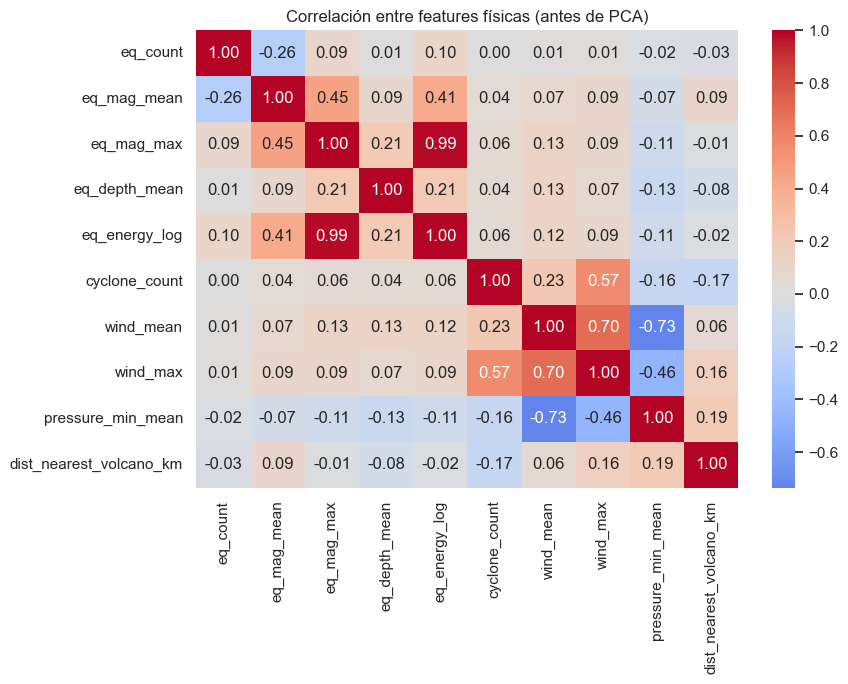

In [11]:
feature_cols = [
    "eq_count", "eq_mag_mean", "eq_mag_max", "eq_depth_mean", "eq_energy_log",
    "cyclone_count", "wind_mean", "wind_max", "pressure_min_mean",
    "dist_nearest_volcano_km",
]

corr = final[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre features físicas (antes de PCA)")
plt.tight_layout()
plt.savefig('../outputs/figures/correlacion_features_pre_pca.png', dpi=200)
plt.show()


### Interpretación esperada

Se espera correlación fuerte dentro de cada grupo de peligro (ej.
`eq_mag_mean` con `eq_energy_log`, o `wind_mean` con `wind_max`), y
correlación débil entre peligros distintos (un sismo y un ciclón no tienen
por qué coexistir en la misma celda). Esta es precisamente la justificación
técnica que necesita Persona 4 para aplicar PCA de forma no forzada: hay
redundancia real dentro de cada bloque de variables que PCA puede
comprimir sin perder información relevante.

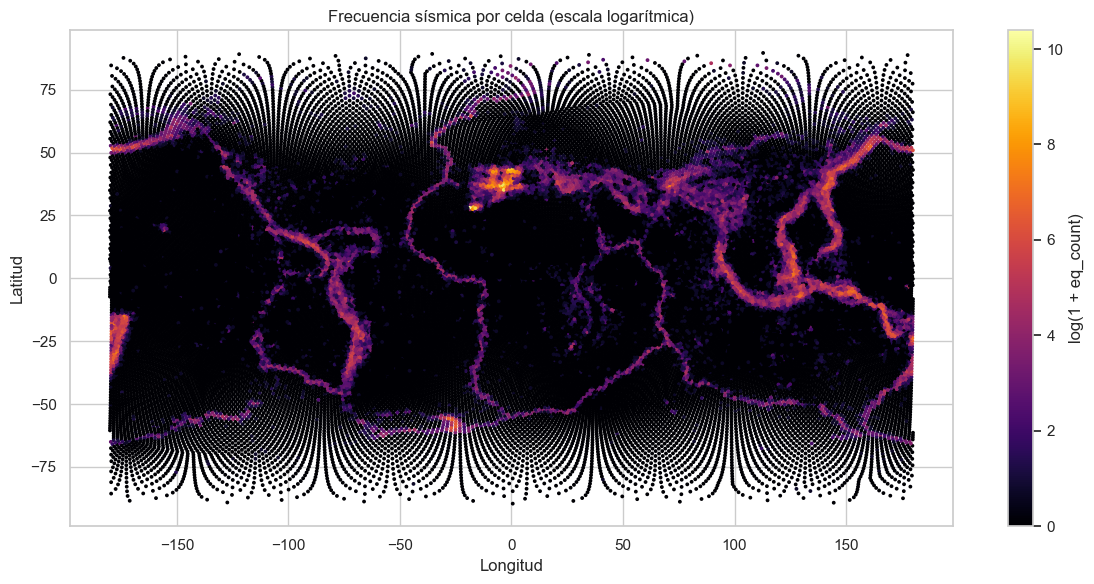

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    final['lon'], final['lat'],
    c=np.log1p(final['eq_count']),
    cmap='inferno', s=3,
)
plt.colorbar(sc, label='log(1 + eq_count)')
ax.set_title('Frecuencia sísmica por celda (escala logarítmica)')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.savefig('../outputs/figures/mapa_frecuencia_sismica.png', dpi=200)
plt.show()


El patrón esperado (y que debería confirmarse visualmente aquí) es el
"Cinturón de Fuego del Pacífico" y las zonas de subducción — si el mapa no
muestra esta estructura reconocible, sería señal de un problema en la
asignación de coordenadas a celdas, no solo un resultado a comentar.

## 7. Exportación Features

In [13]:
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "grid_features.csv"
final.to_csv(OUTPUT_PATH, index=False)
print(f"Guardado en: {OUTPUT_PATH}")
print(f"Filas: {len(final):,} | Columnas: {final.shape[1]}")


Guardado en: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\data\processed\grid_features.csv
Filas: 41,162 | Columnas: 15


## Resumen para la integración con el equipo (Persona 4)

### Configuración aplicada

- Resolución H3: 3 (~100-200 km de lado)
- Ventana sísmica: 1900-2025
- Ventana de ciclones: 1970-2025
- Volcanes: histórico completo, sin recorte temporal

### Columnas y qué significa un NaN en cada una

| Columna | NaN tras `fillna` inicial significa |
|---|---|
| `eq_count`, `cyclone_count` | Nunca (ya rellenado con 0 = sin eventos) |
| `eq_mag_mean`, `eq_mag_max`, `eq_depth_mean`, `eq_energy_log`, `eq_days_since_last_major` | Sin sismos en la celda (`eq_count == 0`) |
| `wind_mean`, `wind_max`, `pressure_min_mean` | Puede ser (a) sin ciclones (`cyclone_count == 0`), o (b) hubo ciclones pero sin dato de intensidad disponible — **distinguir ambos casos antes de imputar** |
| `dist_nearest_volcano_km` | Nunca (siempre calculable) |

### Pendiente para Persona 4

1. Decidir estrategia de imputación para el caso (b) de `wind_mean`/`pressure_min_mean`
   (recomendado: imputar con la media global en vez de 0, o mantener como
   variable separada indicando "intensidad desconocida").
2. Transformación logarítmica de variables muy asimétricas (`eq_energy_log`
   ya viene en log; revisar si `eq_count`/`cyclone_count` también lo necesitan).
3. `StandardScaler` + PCA sobre el bloque de variables físicas únicamente
   (sin mezclar con variables de contexto como población/PIB, que se
   incorporan más adelante solo para la interpretación de negocio, no para
   el clustering — ver conversación de equipo sobre discriminación
   algorítmica indirecta).

### Archivo entregado

`data/processed/grid_features.csv` — una fila por celda H3, lista para
escalado y PCA.